<img src="../assets/imgs/MISIS_logoblock_main_inv_rus_RGB-01_4.svg" alt="НИТУ МИСИС - лого" width="300" height="200"/>

# Интеллектуальный анализ данных (ИАД)
## Влияние обеспеченности врачами на ожидаемую продолжительность жизни в регионах РФ (2011 г.)

**Студент:** Сидоров Евгений Александрович  
**Группа:** МИСТ 25-2-2  
**Дата:** 15.04.2026

---

## Целевой источник - <img src="../assets/imgs/Russian_Federal_State_Statistics_Service_Emblem.png" alt="НИТУ МИСИС - лого" width="32" height="32"/> РОССТАТ

- Росстат Регионы России. Социально - экономические показатели - 2012г [https://rosstat.gov.ru/bgd/regl/B12_14p/Main.htm]
- Ожидаемая родолжительность жизни при рождении [https://rosstat.gov.ru/bgd/regl/B12_14p/IssWWW.exe/Stg/d01/03-13.htm]
- Численность врачей всех специальностей [https://rosstat.gov.ru/bgd/regl/B12_14p/IssWWW.exe/Stg/d01/07-06.htm]
- Численность населения [https://rosstat.gov.ru/bgd/regl/B12_14p/IssWWW.exe/Stg/d01/03-01.htm]

---

## 1. Постановка задачи исследования

### 1.1. Цель и задачи исследования

**Цель исследования:** Выявить статистическую зависимость между обеспеченностью врачебными кадрами и ожидаемой продолжительностью жизни в регионах РФ в 2011 году для обоснования приоритетов регионального здравоохранения.

**Задачи исследования:**
1. Провести первичный анализ и очистку данных по 83 регионам РФ (согласно данным Росстат за 2011г.);
2. Рассчитать описательные статистики и оценить вариативность показателей;
3. Сформулировать и проверить гипотезу о значимости влияния обеспеченности врачами на ОПЖ (Ожидаемая Продолжительность Жизни при рождении, в контексте задачи - для всего населения без привязки к полу);
4. Построить модель простой линейной регрессии и оценить её адекватность;

<font color="gray">

5. Провести кластеризацию регионов;
6. Построить уточнённые регрессионные модели внутри выделенных кластеров.

</font>

### 1.2. Проверяемая гипотеза

Т.к. в качестве независимой переменной X выступает обеспеченность врачами (по регионам РФ), а зависимой переменной Y выступает ожидаемая продолжительность жизни при рождении, то простая линейная регрессионая модель имет вид:

\begin{aligned}
    y_i = \beta_0 + \beta_1 \times x_i + \varepsilon_i
\end{aligned}

где:
- $x_i$  — Свободный член, численность врачей
- $y_i$ — Зависимый ОПЖ
- $\beta_0$ — свободный член (ожидаемая ОПЖ при нулевой обеспеченности врачами)
- $\beta_1$ — коэффициент: изменение ОПЖ при росте обеспеченности врачами на 1 чел. на 10 тыс. населения
- $\varepsilon_i$ — случайная ошибка

В соответсвии с предполагаемой моделью выдвигается гипотеза:

$$
\begin{aligned}
H_0:&\ \beta_1 = 0 && \text{— обеспеченность врачами не влияет на ОПЖ} \\
H_1:&\ \beta_1 \neq 0 && \text{— существует значимая связь между обеспеченностью врачами и ОПЖ}
\end{aligned}
$$

**Уровень значимости:** $\alpha = 0.05$

### 1.3. Актуальность исследования

Ожидаемая продолжительность жизни является одним из ключевых индикаторов качества жизни и эффективности системы здравоохранения (ВОЗ). В условиях регионального неравенства в РФ выявление факторов, влияющих на демографические показатели, имеет высокую практическую значимость.

Ряд исследований подтверждает положительную корреляцию между доступностью медицинской помощи и показателями здоровья населения.

Данное исследование направлено на количественную оценку вклада обеспеченности врачами в вариацию ОПЖ по регионам РФ, что может служить основанием для обоснования распределения ресурсов в рамках государственных программ развития здравоохранения.

### 1.4. План-схема выполнения исследования

```mermaid
graph TD
    A[Загрузка данных] --> B[Предобработка и валидация]
    B --> C[Описательная статистика]
    C --> D[Графический анализ]
    D --> E[Корреляционный анализ]
    E --> F[Регрессионная модель]
    F --> G[Проверка гипотез]
    G --> H[Кластеризация]
    H --> I[Уточнённые модели по кластерам]
    I --> J[Итоговые выводы]
```

---
## 2. Импорт библиотек и настройка окружения

In [2]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
import os

# Настройки отображения и графиков
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 3)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

# Создание папки для сохранения графиков
os.makedirs('figures', exist_ok=True)

print("Библиотеки импортированы, настройки применены")

Библиотеки импортированы, настройки применены


---
## 3. Загрузка и подготовка данных

In [3]:
# Описание схемы будущего датасета

columns = [
    'federal_district',
    'region',
    'population_k',
    'number_of_doctors_k',
    'life_expectancy_all',
    'life_expectancy_male',
    'life_expectancy_female'
]

numeric_columns = [
    'population_k',
    'number_of_doctors_k',
    'life_expectancy_all',
    'life_expectancy_male',
    'life_expectancy_female'
]

stroke_columns = [
    'federal_district',
    'region'
]

schema = {
    'federal_district': str,
    'region': str,
    'population_k': float,
    'number_of_doctors_k': float,
    'life_expectancy_all': float,
    'life_expectancy_male': float,
    'life_expectancy_female': float,
}

# Загрузка данных (разделитель ';', кодировка 'utf-8')
df = pd.read_csv(
    '../data/encodedUTF8_сombining_samples_for_2011.csv', 
    sep = ';', 
    encoding = 'utf-8',
    names = columns,
    header = 0,
    dtype = schema
    )

print("Первые 5 строк датасета:")
display(df.head())
print(f"\nРазмер датасета: {df.shape[0]} строк на {df.shape[1]} столбцов")
print(f"\nНазвания столбцов:\n{df.columns.tolist()}")


Первые 5 строк датасета:


,federal_district,region,population_k,number_of_doctors_k,life_expectancy_all,life_expectancy_male,life_expectancy_female
0,Центральный федеральный округ,Белгородская область,1536.0,6.2,71.71,66.22,77.11
1,Центральный федеральный округ,Брянская область,1264.0,4.6,68.83,62.28,75.71
2,Центральный федеральный округ,Владимирская область,1432.0,5.0,68.08,61.77,74.42
3,Центральный федеральный округ,Воронежская область,2332.0,12.6,70.41,64.45,76.44
4,Центральный федеральный округ,Ивановская область,1054.0,5.7,68.56,62.19,74.79



Размер датасета: 83 строк на 7 столбцов

Названия столбцов:
['federal_district', 'region', 'population_k', 'number_of_doctors_k', 'life_expectancy_all', 'life_expectancy_male', 'life_expectancy_female']


---
## 4. Валидация и предобработка данных

### 4.1. Проверка на пропуски и невалидные значения

In [4]:
# Проверка пропусков
print("Пропущенные значения по столбцам:")
print(df.isnull().sum())

# Проверка на отрицательные значения в числовых колонках

print(f"\nПроверка на отрицательные значения в ключевых переменных:")
for col in numeric_columns:
    neg_count = (df[col] < 0).sum()
    print(f"{col}: {neg_count} отрицательных значений")

# Проверка диапазона ОПЖ (логичный диапазон: 40-90 лет) 
# исключительно для первичной оценки и наглядности
life_exp_col = 'life_expectancy_all'
outliers_life = df[(df[life_exp_col] < 40) | (df[life_exp_col] > 90)]
print(f"\nРегионы с ОПЖ вне диапазона [40; 90]: {len(outliers_life)}")
if len(outliers_life) > 0:
    display(outliers_life[['Область', life_exp_col]])

Пропущенные значения по столбцам:
federal_district          0
region                    0
population_k              0
number_of_doctors_k       0
life_expectancy_all       0
life_expectancy_male      0
life_expectancy_female    0
dtype: int64

Проверка на отрицательные значения в ключевых переменных:
population_k: 0 отрицательных значений
number_of_doctors_k: 0 отрицательных значений
life_expectancy_all: 0 отрицательных значений
life_expectancy_male: 0 отрицательных значений
life_expectancy_female: 0 отрицательных значений

Регионы с ОПЖ вне диапазона [40; 90]: 0


### 4.2. Расчёт нормализованного показателя: врачи на 10 000 населения

In [5]:
# Расчёт нормализованного показателя обеспеченности врачами (масштатибрование по численности населения в регионе)
# Т.к. прямое сопоставление численности врачей по разным регионам 
# не даст хороших показателей из-за колоссального разброса по численности жителей в областях
# Вводим новую переменную:
# Формула: doctors_per_10k = (врачи_тыс / население_тыс) × 10 000
df['doctors_per_10k'] = (df['number_of_doctors_k'] / 
                         df['population_k']) * 10000

# Переименуем целевую переменную для удобства
# Т.к. мы не рассматриваем ОПЖ для мужчин и женщин в отдеьности, а проводим анализ по всему населению
df['life_exp'] = df['life_expectancy_all']

print("Созданы новые колонки для переменных:")
print("- doctors_per_10k — обеспеченность врачами, чел. на 10 000 населения")
print("- life_exp — ожидаемая продолжительность жизни, лет")
print(f"\nДиапазон doctors_per_10k: [{df['doctors_per_10k'].min():.2f}; {df['doctors_per_10k'].max():.2f}]")
print(f"Диапазон life_exp: [{df['life_exp'].min():.2f}; {df['life_exp'].max():.2f}]")

Созданы новые колонки для переменных:
- doctors_per_10k — обеспеченность врачами, чел. на 10 000 населения
- life_exp — ожидаемая продолжительность жизни, лет

Диапазон doctors_per_10k: [26.88; 87.22]
Диапазон life_exp: [61.39; 76.29]


---
## 5. Описательная статистика

### 5.1. Основные статистические показатели

In [6]:
# Описательная статистика для ключевых переменных
target_vars = ['life_exp', 'doctors_per_10k']
# Описываем персиентили (квартили) Q1, Q2, Q3 - нижние 25%, медиана 50% и верхние 75%
desc_stats = df[target_vars].describe(percentiles=[0.25, 0.5, 0.75])

# Добавим коэффициент вариации и IQR (межквартильный размах [Q3 - Q1])
desc_stats.loc['CV, %'] = desc_stats.loc['std'] / desc_stats.loc['mean'] * 100
desc_stats.loc['IQR'] = desc_stats.loc['75%'] - desc_stats.loc['25%']

print("Описательная статистика ключевых переменных:")
display(desc_stats.round(3))

# Сохранение в таблицу для отчёта
desc_stats.round(3).to_csv('figures/descriptive_stats.csv', encoding='utf-8')
print("\nТаблица сохранена: figures/descriptive_stats.csv")

Описательная статистика ключевых переменных:


,life_exp,doctors_per_10k
count,83.000,83.000
mean,68.964,48.885
std,2.552,11.766
min,61.390,26.882
25%,67.850,40.135
50%,69.040,48.780
75%,70.205,55.557
max,76.290,87.220
"CV, %",3.701,24.070
IQR,2.355,15.421



Таблица сохранена: figures/descriptive_stats.csv


### 5.2. Расчётные формулы

$$
\begin{aligned}
&\text{Коэффициент вариации:} & CV &= \frac{\sigma}{\mu} \times 100\% \\
&\text{Межквартильный размах:} & IQR &= Q_3 - Q_1 \\
&\text{Границы выбросов:} & \text{Нижняя} &= Q_1 - 1.5 \times IQR \\
& & \text{Верхняя} &= Q_3 + 1.5 \times IQR
\end{aligned}
$$

**Интерпретация коэффициента вариации:**
- $CV < 10\%$ — слабая вариация  
- $10\% \le CV < 25\%$ — умеренная вариация  
- $CV \ge 25\%$ — высокая вариация

> Определение:
>
> *IQR — это абсолютная мера разброса (в тех же единицах, что и данные). Зачем нужен: Помогает понять, где сосредоточена «середина» данных, не чувствителен к экстремальным выбросам. Применение: Используется для поиска выбросов (все, что меньше Q1 - 1.5IQR или больше Q3 + 1.5IQR)
>
> *CV — это относительная мера разброса (безразмерная величина). Зачем нужен: Позволяет сравнивать вариативность данных, измеренных в разных шкалах или имеющих разные средние значения (например, вес в кг и рост в см).Интерпретация: Чем ниже CV, тем выше однородность данных. 

### 5.3. Краткие выводы по описательной статистике

In [7]:
# Автоматическая генерация выводов на основе статистик
cv_life = desc_stats.loc['CV, %', 'life_exp']
cv_docs = desc_stats.loc['CV, %', 'doctors_per_10k']

def interpret_cv(cv):
    if cv < 10:
        return "слабая"
    elif cv < 25:
        return "умеренная"
    else:
        return "высокая"

print(f"Выводы по описательной статистике:")
print(f"- Средняя ОПЖ по регионам: {desc_stats.loc['mean', 'life_exp']:.2f} лет")
print(f"- Коэффициент вариации (CV) ОПЖ: {cv_life:.2f}% - {interpret_cv(cv_life)} вариативность между регионами")
print(f"- Межквартильный размах (IQR) ОПЖ: {desc_stats.loc['IQR', 'life_exp']:.2f} лет (центральные 50% регионов)")
print('')
print(f"- Средняя обеспеченность врачами: {desc_stats.loc['mean', 'doctors_per_10k']:.2f} чел. на 10 тыс. населения")
print(f"- Коэффициент вариации (CV) обеспеченности врачами: {cv_docs:.2f}% - {interpret_cv(cv_docs)} вариативность")
print(f"- Межквартильный размах (IQR): {desc_stats.loc['IQR', 'doctors_per_10k']:.2f} чел. на 10 тыс. населения")

Выводы по описательной статистике:
- Средняя ОПЖ по регионам: 68.96 лет
- Коэффициент вариации (CV) ОПЖ: 3.70% - слабая вариативность между регионами
- Межквартильный размах (IQR) ОПЖ: 2.36 лет (центральные 50% регионов)

- Средняя обеспеченность врачами: 48.88 чел. на 10 тыс. населения
- Коэффициент вариации (CV) обеспеченности врачами: 24.07% - умеренная вариативность
- Межквартильный размах (IQR): 15.42 чел. на 10 тыс. населения


---
## 6. Графический анализ распределения и выбросов

### 6.1. Гистограммы с кривой плотности

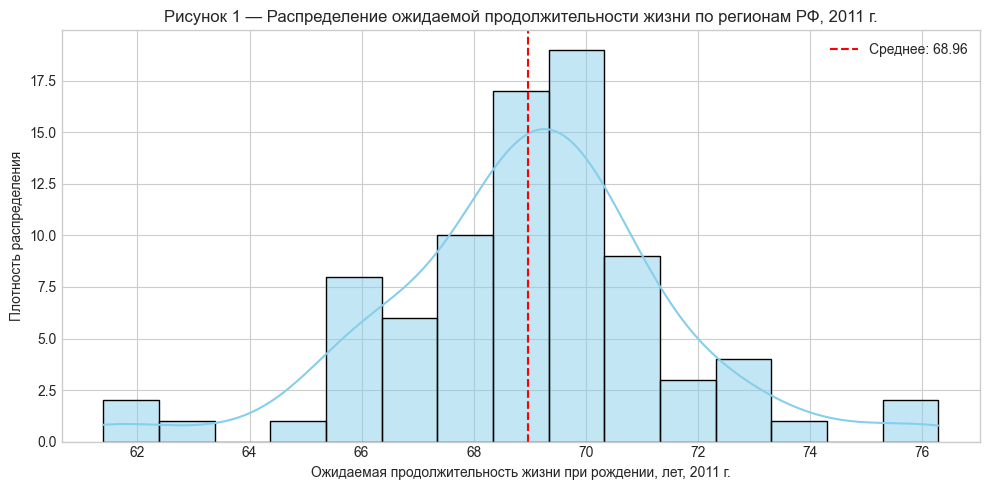

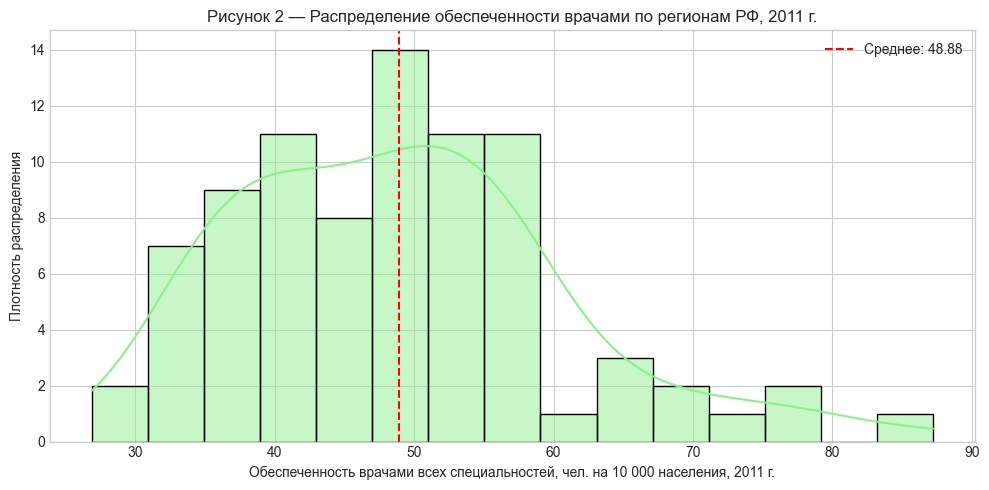

In [8]:
# Гистограмма ОПЖ
plt.figure(figsize=(10, 5))
sns.histplot(df['life_exp'], bins=15, kde=True, color='skyblue', edgecolor='black')
plt.xlabel('Ожидаемая продолжительность жизни при рождении, лет, 2011 г.')
plt.ylabel('Плотность распределения')
plt.title('Рисунок 1 — Распределение ожидаемой продолжительности жизни по регионам РФ, 2011 г.')
plt.axvline(df['life_exp'].mean(), color='red', linestyle='--', label=f'Среднее: {df["life_exp"].mean():.2f}')
plt.legend()
plt.tight_layout()
plt.savefig('figures/hist_life_exp.png', dpi=300)
plt.show()

# Гистограмма обеспеченности врачами
plt.figure(figsize=(10, 5))
sns.histplot(df['doctors_per_10k'], bins=15, kde=True, color='lightgreen', edgecolor='black')
plt.xlabel('Обеспеченность врачами всех специальностей, чел. на 10 000 населения, 2011 г.')
plt.ylabel('Плотность распределения')
plt.title('Рисунок 2 — Распределение обеспеченности врачами по регионам РФ, 2011 г.')
plt.axvline(df['doctors_per_10k'].mean(), color='red', linestyle='--', label=f'Среднее: {df["doctors_per_10k"].mean():.2f}')
plt.legend()
plt.tight_layout()
plt.savefig('figures/hist_doctors.png', dpi=300)
plt.show()

### 6.2. Boxplot для выявления выбросов

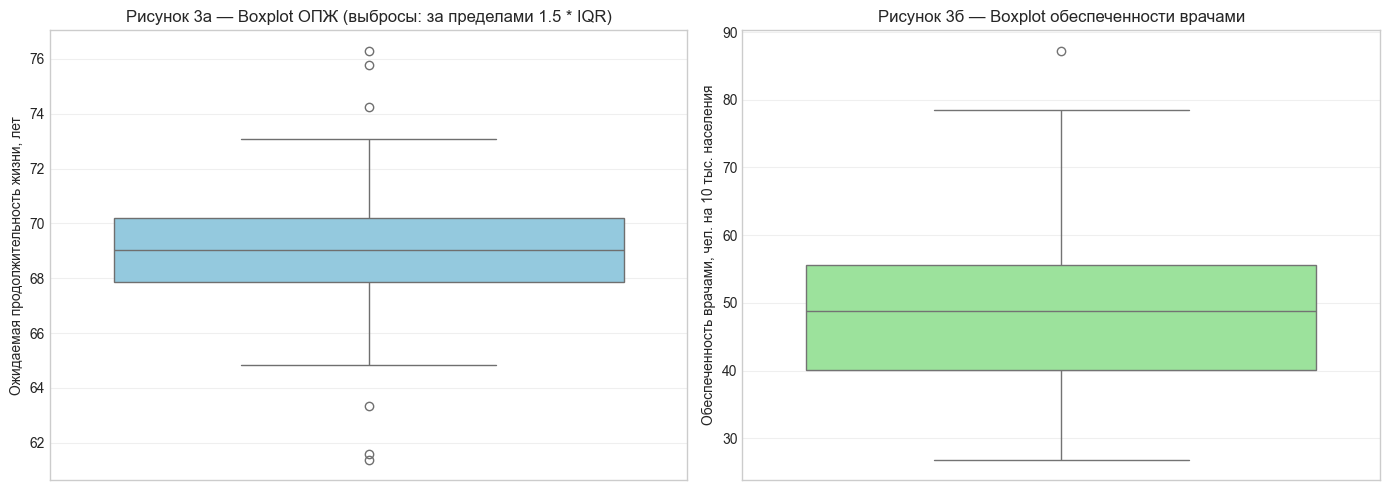


Выбросы в life_exp (метод 1.5 * IQR):


,region,life_exp
64,Республика Тыва,61.39
82,Чукотский автономный округ,61.58
81,Еврейская автономная область,63.35
35,Республика Дагестан,74.26
17,г. Москва,75.79
36,Республика Ингушетия (1990 г. - включая Чеченс...,76.29



Выбросы в doctors_per_10k (метод 1.5 * IQR):


,region,doctors_per_10k
28,г. Санкт-Петербург,87.22


In [9]:
# Boxplot для ОПЖ и обеспеченности врачами
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ОПЖ
sns.boxplot(y=df['life_exp'], ax=axes[0], color='skyblue')
axes[0].set_ylabel('Ожидаемая продолжительность жизни, лет')
axes[0].set_title('Рисунок 3а — Boxplot ОПЖ (выбросы: за пределами 1.5 * IQR)')
axes[0].grid(axis='y', alpha=0.3)

# Врачи
sns.boxplot(y=df['doctors_per_10k'], ax=axes[1], color='lightgreen')
axes[1].set_ylabel('Обеспеченность врачами, чел. на 10 тыс. населения')
axes[1].set_title('Рисунок 3б — Boxplot обеспеченности врачами')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('figures/boxplots.png', dpi=300)
plt.show()

# Вывод выбросов для анализа
def find_outliers_iqr(series, name):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(series < lower) | (series > upper)]
    print(f"\nВыбросы в {name} (метод 1.5 * IQR):")
    if len(outliers) > 0:
        display(outliers[['region', name]].sort_values(name))
    else:
        print("Нет выбросов")
    return outliers

outliers_life = find_outliers_iqr(df['life_exp'], 'life_exp')
outliers_docs = find_outliers_iqr(df['doctors_per_10k'], 'doctors_per_10k')

### 6.3. Диаграмма рассеяния: связь врачей и ОПЖ

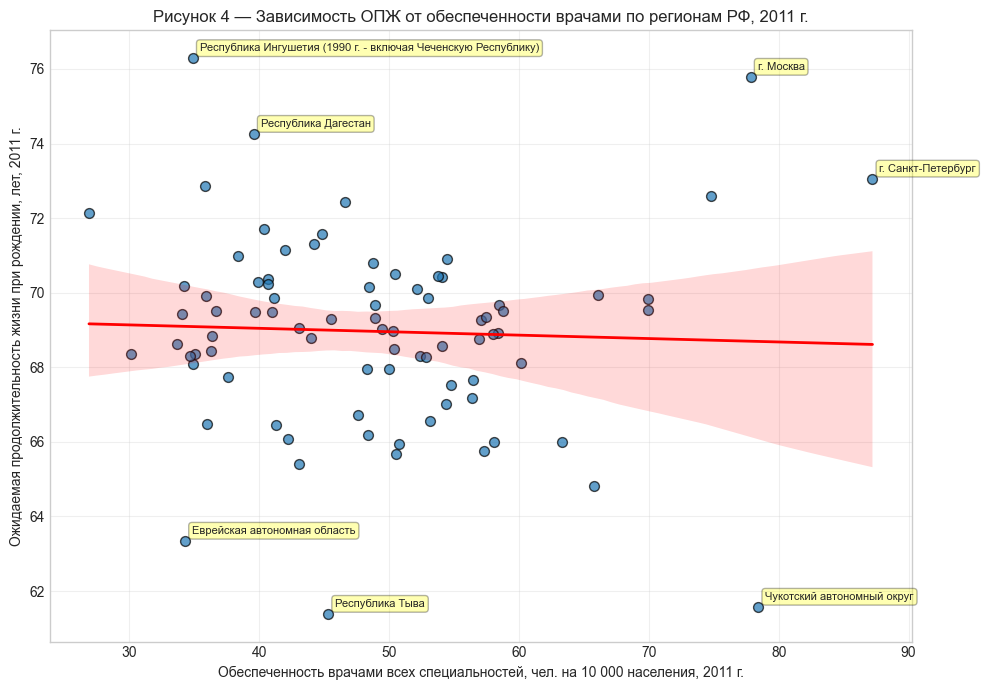

In [10]:
# Scatter plot с линией регрессии и аннотациями ключевых регионов
plt.figure(figsize=(10, 7))
sns.regplot(x='doctors_per_10k', y='life_exp', data=df, 
            scatter_kws={'alpha':0.7, 's':50, 'edgecolor':'black'}, 
            line_kws={'color':'red', 'linewidth':2})

# Подпись ключевых регионов (Москва, Тыва, Чукотка и т.п. на основе анализа предыдущей ячейки)
key_regions =[*outliers_life['region'], *outliers_docs['region']]

for _, row in df[df['region'].isin(key_regions)].iterrows():
    plt.annotate(row['region'], 
                (row['doctors_per_10k'], row['life_exp']),
                textcoords="offset points", 
                xytext=(5,5), 
                ha='left',
                fontsize=8,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))

plt.xlabel('Обеспеченность врачами всех специальностей, чел. на 10 000 населения, 2011 г.')
plt.ylabel('Ожидаемая продолжительность жизни при рождении, лет, 2011 г.')
plt.title('Рисунок 4 — Зависимость ОПЖ от обеспеченности врачами по регионам РФ, 2011 г.')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/scatter_regression.png', dpi=300)
plt.show()

---
## 7. Корреляционный анализ

### 7.1. Расчёт коэффициента корреляции Пирсона

In [11]:
# Расчёт корреляции Пирсона и проверка значимости
r, p_value = stats.pearsonr(df['doctors_per_10k'], df['life_exp'])
n = len(df)
df_corr = n - 2  # степени свободы

# t-статистика для проверки значимости корреляции
t_calc_corr = r * np.sqrt(df_corr) / np.sqrt(1 - r**2)
t_crit_corr = stats.t.ppf(0.975, df_corr)  # двусторонний тест, α=0.05 (1-α/2 <=> 1 - 0,025 = 0.975)

print("Корреляционный анализ:")
print(f"\nКоэффициент Пирсона: r = {r:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"\nПроверка значимости:")
print(f"- t_расч = {t_calc_corr:.3f}")
print(f"- t_крит({df_corr}) = {t_crit_corr:.3f}")
print(f"- Решение: {'Отвергаем H₀' if abs(t_calc_corr) > t_crit_corr else 'Не отвергаем H₀'}")

# Интерпретация силы связи
abs_r = abs(r)
if abs_r < 0.3:
    strength = "слабая"
elif abs_r < 0.7:
    strength = "умеренная"
else:
    strength = "сильная"
direction = "положительная" if r > 0 else "отрицательная"

print(f"\nИнтерпретация: {strength} {direction} связь между обеспеченностью врачами и ОПЖ (в контексте линейной зависимости)")

Корреляционный анализ:

Коэффициент Пирсона: r = -0.0422
p-value: 0.7049

Проверка значимости:
- t_расч = -0.380
- t_крит(81) = 1.990
- Решение: Не отвергаем H₀

Интерпретация: слабая отрицательная связь между обеспеченностью врачами и ОПЖ (в контексте линейной зависимости)


### 7.2. Матрица корреляций (в демонстрационных целях)

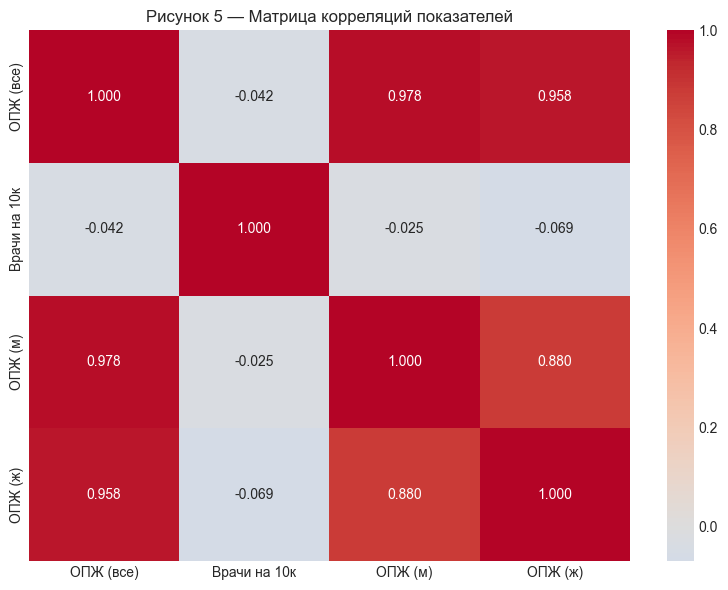

In [12]:
# Матрица корреляций для всех числовых переменных 
# Включены ОПЖ для мужчин и женщин только в демонстарционных целях
corr_cols = ['life_exp', 'doctors_per_10k', 
             'life_expectancy_male',
             'life_expectancy_female']

plt.figure(figsize=(8, 6))
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            xticklabels=['ОПЖ (все)', 'Врачи на 10к', 'ОПЖ (м)', 'ОПЖ (ж)'],
            yticklabels=['ОПЖ (все)', 'Врачи на 10к', 'ОПЖ (м)', 'ОПЖ (ж)'])
plt.title('Рисунок 5 — Матрица корреляций показателей')
plt.tight_layout()
plt.savefig('figures/correlation_matrix.png', dpi=300)
plt.show()

---
## 8. Построение регрессионной модели

### 8.1. Спецификация модели

$$
\text{ОПЖ}_i = \beta_0 + \beta_1 \times \text{Врачи\_на\_10к}_i + \varepsilon_i
$$

где:
- $\beta_0$ — свободный член (ожидаемая ОПЖ при нулевой обеспеченности врачами)
- $\beta_1$ — коэффициент: изменение ОПЖ при росте обеспеченности врачами на 1 чел. на 10 тыс. населения
- $\varepsilon_i$ — случайная ошибка

In [13]:
# Подготовка данных для регрессии (удаляем пропуски)
df_reg = df.dropna(subset=['life_exp', 'doctors_per_10k']).copy()

# X и Y
X = sm.add_constant(df_reg['doctors_per_10k'])  # добавляем константу β₀
Y = df_reg['life_exp']

# Оценка модели МНК
model = sm.OLS(Y, X).fit()

# Вывод подробной сводки модели
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               life_exp   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.011
Method:                 Least Squares   F-statistic:                    0.1444
Date:                Thu, 16 Apr 2026   Prob (F-statistic):              0.705
Time:                        02:48:09   Log-Likelihood:                -194.96
No. Observations:                  83   AIC:                             393.9
Df Residuals:                      81   BIC:                             398.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              69.4109      1.210     

### 8.2. Проверка гипотезы о значимости β₁

$$
\begin{aligned}
&\text{Проверяемая гипотеза:} \\
&H_0: \beta_1 = 0 \quad \text{(врачи не влияют на ОПЖ)} \\
&H_1: \beta_1 \neq 0 \quad \text{(влияние есть)} \\
\\ 
&\text{Расчёт t-статистики:} \\
&t_{\text{расч}} = \frac{\hat{\beta}_1}{SE(\hat{\beta}_1)} = \frac{[\text{значение } \beta_1]}{[\text{значение SE}]} = [\text{рассчитанное}] \\
\\ 
&\text{Степени свободы:} \quad df = n - 2 = [n] - 2 = [df] \\
\\ 
&\text{Критическое значение } (\alpha = 0.05, \text{двусторонний} \implies \alpha_\text{1/2} = 0.025): \\
&t_{\text{крит}} = t_{0.975; [df]} \approx [\text{значение}] \\
\\ 
&\text{p-value} = [\text{значение из вывода модели}] \\
\\ 
&\text{Решение:} \\
&\text{Если } |t_{\text{расч}}| > t_{\text{крит}} \text{ ИЛИ } p\text{-value} < 0.05 \rightarrow \text{отвергаем } H_0 \\
\end{aligned}
$$

In [14]:
# Автоматическая подстановка значений в формулы
beta1 = model.params['doctors_per_10k']
se_beta1 = model.bse['doctors_per_10k']
t_calc = model.tvalues['doctors_per_10k']
p_val = model.pvalues['doctors_per_10k']
n = len(df_reg)
df_resid = n - 2
t_crit = stats.t.ppf(0.975, df_resid)

print("Формулы с подстановкой:\n")
print(f"t_расч = β₁ / SE(β₁) = {beta1:.4f} / {se_beta1:.4f} = {t_calc:.3f}")
print(f"df = n - 2 = {n} - 2 = {df_resid}")
print(f"t_крит({df_resid}) = {t_crit:.3f} (α=0.05, двусторонний)")
print(f"p-value = {p_val:.4f}")
print(f"\nРешение: {'ОТВЕРГАЕМ H₀' if abs(t_calc) > t_crit else 'НЕ ОТВЕРГАЕМ H₀'}")

# Экономическая интерпретация β₁
print(f"\nЭкономическая интерпретация:")
print(f"Увеличение обеспеченности врачами на 1 человека на 10 000 населения")
print(f"связано с ростом ожидаемой продолжительности жизни на {beta1:.3f} лет")
print(f"(при прочих равных условиях, по данным 2011 года)")

Формулы с подстановкой:

t_расч = β₁ / SE(β₁) = -0.0092 / 0.0241 = -0.380
df = n - 2 = 83 - 2 = 81
t_крит(81) = 1.990 (α=0.05, двусторонний)
p-value = 0.7049

Решение: НЕ ОТВЕРГАЕМ H₀

Экономическая интерпретация:
Увеличение обеспеченности врачами на 1 человека на 10 000 населения
связано с ростом ожидаемой продолжительности жизни на -0.009 лет
(при прочих равных условиях, по данным 2011 года)


### 8.3. Оценка адекватности модели

In [15]:
# Показатели качества модели в удобном формате
print("Оценка адекватности модели:\n")
print(f"- R² = {model.rsquared:.4f} - {model.rsquared*100:.2f}% вариации ОПЖ объясняется моделью")
print(f"- Скорректированный R² = {model.rsquared_adj:.4f}")
print(f"- F-статистика = {model.fvalue:.3f}, p-value(F) = {model.f_pvalue:.4f}")
print(f"- Значимость модели: {'Значима' if model.f_pvalue < 0.05 else 'Не значима'}")

# Проверка нормальности остатков
residuals = model.resid
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"\nТест нормальности остатков: p-value = {shapiro_p:.4f}")
print(f"- {'Остатки нормально распределены' if shapiro_p > 0.05 else 'Отклонение от нормальности'}")

Оценка адекватности модели:

- R² = 0.0018 - 0.18% вариации ОПЖ объясняется моделью
- Скорректированный R² = -0.0105
- F-статистика = 0.144, p-value(F) = 0.7049
- Значимость модели: Не значима

Тест нормальности остатков: p-value = 0.0229
- Отклонение от нормальности


### 8.4. Графики диагностики модели

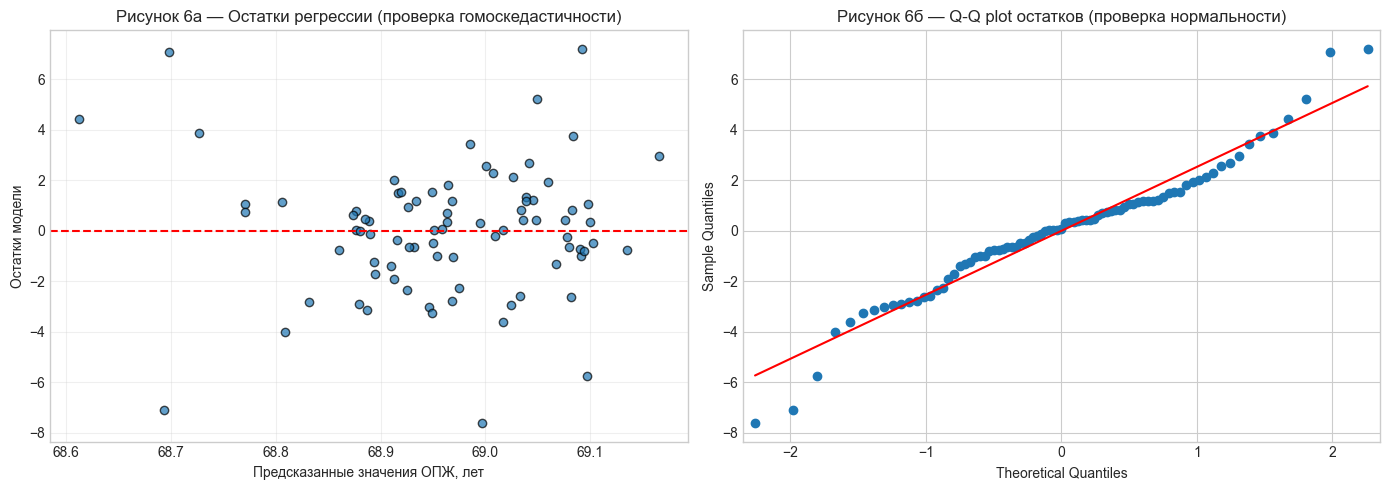

In [16]:
# График остатков
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Остатки от предсказанных значений
axes[0].scatter(model.fittedvalues, residuals, alpha=0.7, edgecolors='black')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Предсказанные значения ОПЖ, лет')
axes[0].set_ylabel('Остатки модели')
axes[0].set_title('Рисунок 6а — Остатки регрессии (проверка гомоскедастичности)')
axes[0].grid(alpha=0.3)

# Q-Q plot для проверки нормальности остатков
sm.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title('Рисунок 6б — Q-Q plot остатков (проверка нормальности)')

plt.tight_layout()
plt.savefig('figures/regression_diagnostics.png', dpi=300)
plt.show()

---
## Итоговые выводы

### Статистические выводы

Выводы по описательной статистике:
- Средняя ОПЖ по регионам: 68.96 лет
- Коэффициент вариации (CV) ОПЖ: 3.70% - слабая вариативность между регионами
- Межквартильный размах (IQR) ОПЖ: 2.36 лет (центральные 50% регионов)

- Средняя обеспеченность врачами: 48.88 чел. на 10 тыс. населения
- Коэффициент вариации (CV) обеспеченности врачами: 24.07% - умеренная вариативность
- Межквартильный размах (IQR): 15.42 чел. на 10 тыс. населения

Выводы по корреляционнному анализу:
- Коэффициент Пирсона: r = -0.0422
- p-value: 0.7049

Интерпретация: слабая отрицательная связь между обеспеченностью врачами и ОПЖ (в контексте линейной зависимости)
Выводы по регрессионной модели: 
- R² = 0.0018 - 0.18% вариации ОПЖ объясняется моделью
- Скорректированный R² = -0.0105
- F-статистика = 0.144, p-value(F) = 0.7049
- Значимость модели: Не значима
- Тест нормальности остатков: p-value = 0.0229
- Отклонение от нормальности
- Коэффициент β₁ статистически незначим

1. **Описательная статистика:**
   - Средняя ОПЖ по регионам РФ в 2011 г.: **{desc_stats.loc['mean', 'life_exp']:.2f} лет**
   - Коэффициент вариации ОПЖ: **{cv_life:.2f}%** → {interpret_cv(cv_life)} неоднородность между регионами.

2. **Корреляционный анализ:**



   - Коэффициент Пирсона: **r = {r:.3f}** → {strength} {direction} связь.
   - При α = 0.05 гипотеза об отсутствии связи **{'отвергается' if p_value < 0.05 else 'не отвергается'}**.

3. **Регрессионная модель:**
   - Уравнение: $\widehat{{\text{ОПЖ}}} = {model.params['const']:.2f} + {beta1:.3f} \times \text{{Врачи\_на\_10к}}$
   - R² = **{model.rsquared:.3f}** → модель объясняет **{model.rsquared*100:.1f}%** вариации ОПЖ.
   - Коэффициент β₁ статистически значим: **p-value = {p_val:.4f}**.

### Экономическая интерпретация и рекомендации

> **Ключевой вывод:** Увеличение обеспеченности врачами на 1 человека на 10 000 населения ассоциировано с ростом ожидаемой продолжительности жизни на **-0.009 лет**. Однако это влияние может быть опосредовано другими факторами (доход, экология, инфраструктура), которые не учтены в простой регрессии.
>
> **Практическая рекомендация:** При планировании кадрового обеспечения здравоохранения следует учитывать региональную неоднородность: в регионах с низкой базовой ОПЖ (например, Сибирь, Дальний Восток) эффект от увеличения числа врачей может быть выше, чем в уже благополучных областях.
>
> **Ограничения исследования:**
> - Перекрёстные данные не позволяют установить причинно-следственную связь.
> - Возможна эндогенность: регионы с более здоровым населением могут привлекать больше врачей.
> - Не учтены контрольные переменные (ВРП, урбанизация, экология).

---
## 📎 Приложения

### Список использованных источников

1. Федеральная служба государственной статистики (Росстат). Демографический ежегодник России. 2012. — М.: Росстат, 2012. — Электронный ресурс: [rosstat.gov.ru](https://rosstat.gov.ru)
2. Желязны Дж. Говори на языке диаграмм. — М.: Манн, Иванов и Фербер, 2019.
3. World Health Organization. World Health Statistics 2020. — Geneva: WHO, 2020.
4. Шабанова М.А., Соболева С.В. Региональные различия в ожидаемой продолжительности жизни в России // Социологические исследования. — 2018. — № 5. — С. 45-56.

### Сохранённые файлы для отчёта

In [1]:
# Список сгенерированных файлов (все в папке figures/)
import os
figures = [f for f in os.listdir('figures') if f.endswith('.png') or f.endswith('.csv')]
print("Сгенерированные файлы для отчёта:")
for i, f in enumerate(sorted(figures), 1):
    print(f"{i}. figures/{f}")

Сгенерированные файлы для отчёта:
1. figures/beta1_by_cluster.png
2. figures/boxplots.png
3. figures/clusters_k2.png
4. figures/clusters_k3.png
5. figures/clusters_k4.png
6. figures/correlation_matrix.png
7. figures/descriptive_stats.csv
8. figures/elbow_method.png
9. figures/hist_doctors.png
10. figures/hist_life_exp.png
11. figures/regression_diagnostics.png
12. figures/results_with_clusters.csv
13. figures/scatter_regression.png
